In [92]:
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Tuple, Any, Dict, List
from src.utils import load_config, load_data, serialize_data, deserialize_data, get_project_root

In [93]:
def save_to_config(key: str, value: any, filename: str = "config.yaml"):
    """
    Menyimpan key dan value baru LANGSUNG ke file config.yaml
    tanpa merusak path yang sudah ada.
    """
    path_config = get_project_root() / "config" / filename
    
    with open(path_config, "r") as file:
        raw_config = yaml.safe_load(file) or {}
        
    raw_config[key] = value
    
    with open(path_config, "w") as file:
        yaml.dump(raw_config, file, default_flow_style=False, sort_keys=True)
        
    print(f"Berhasil menyimpan permanen: '{key}' ke {filename}")

In [94]:
config = load_config()

In [95]:
config

{'bin_cb_person_cred_hist_length': [-inf, 2.5, 4.5, 8.5, inf],
 'bin_loan_amnt': [-inf, 7500.0, 12500.0, 18000.0, 22000.0, inf],
 'bin_loan_int_rate': [-inf, 6.5, 9.5, 13, 14.5, 15.5, inf],
 'bin_loan_percent_income': [-inf, 0.1, 0.2, 0.3, 0.4, inf],
 'bin_person_age': [0, 23, 28, 100],
 'bin_person_emp_length': [-inf, 0.5, 1.5, 2.5, 4.5, 11.5, inf],
 'bin_person_income': [-inf, 35000.0, 60000.0, 80000.0, inf],
 'categorical_grouping': {'loan_grade': {'E': 'D', 'F': 'D', 'G': 'D'},
  'person_home_ownership': {'OTHER': 'RENT'}},
 'columns_cat': ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'],
 'columns_num': ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 'columns_predictors': ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'person_home_ownershi

In [96]:
path_X_train, path_y_train = config["path_train_clean"]

In [97]:
X_train = deserialize_data(path_X_train)
y_train = deserialize_data(path_y_train)

In [98]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29762,45.0,37500.0,MORTGAGE,1.0,DEBTCONSOLIDATION,B,5000.0,11.49,0.13,N,16.0
2714,25.0,50000.0,RENT,5.0,PERSONAL,A,12000.0,7.88,0.24,N,2.0
50,24.0,78000.0,RENT,4.0,DEBTCONSOLIDATION,D,30000.0,10.99,0.38,Y,4.0
28458,31.0,78504.0,RENT,2.0,EDUCATION,C,10000.0,11.41,0.13,N,7.0
3674,26.0,14000.0,RENT,2.0,VENTURE,B,4000.0,10.99,0.29,N,3.0


In [99]:
X_train.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [100]:
X_train.dtypes

person_age                    float64
person_income                 float64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                     float64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length    float64
dtype: object

In [101]:
df_viz = pd.concat([X_train, y_train], axis=1)

In [102]:
df_viz.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
29762,45.0,37500.0,MORTGAGE,1.0,DEBTCONSOLIDATION,B,5000.0,11.49,0.13,N,16.0,0
2714,25.0,50000.0,RENT,5.0,PERSONAL,A,12000.0,7.88,0.24,N,2.0,0
50,24.0,78000.0,RENT,4.0,DEBTCONSOLIDATION,D,30000.0,10.99,0.38,Y,4.0,1
28458,31.0,78504.0,RENT,2.0,EDUCATION,C,10000.0,11.41,0.13,N,7.0,0
3674,26.0,14000.0,RENT,2.0,VENTURE,B,4000.0,10.99,0.29,N,3.0,1


In [103]:
sns.set_theme(style="whitegrid")

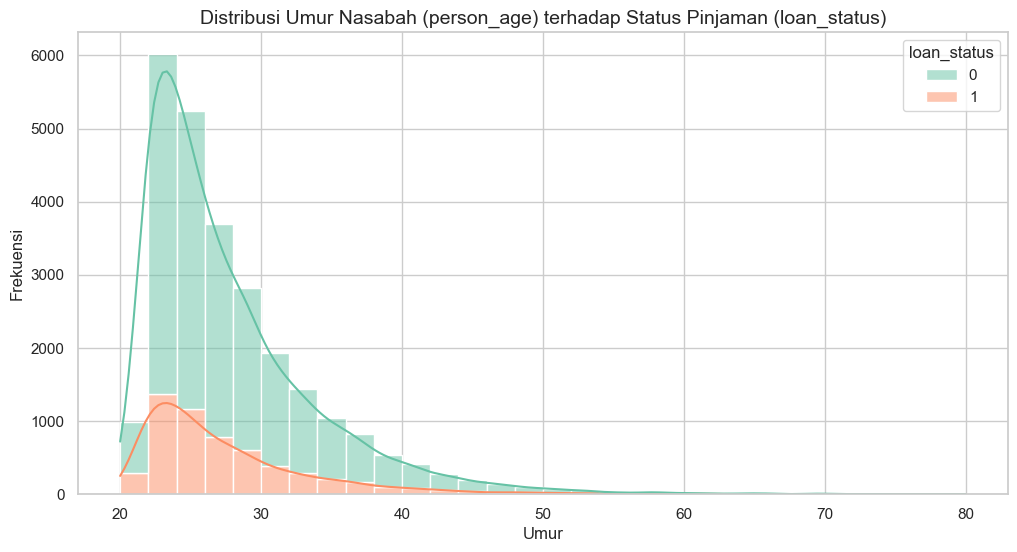

In [104]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_viz, x="person_age", hue="loan_status", kde=True, bins=30, multiple="stack", palette="Set2")
plt.title("Distribusi Umur Nasabah (person_age) terhadap Status Pinjaman (loan_status)", fontsize=14)
plt.xlabel("Umur")
plt.ylabel("Frekuensi")
plt.show()

In [105]:
bins_age = [0, 22, 25, 30, 40, 100]
df_viz["age_binned"] = pd.cut(df_viz["person_age"], bins=bins_age)

age_bin_sum = df_viz.groupby("age_binned", observed=False).agg(
    Total_Nasabah=("loan_status", "count"),
    Total_GalBay=("loan_status", "sum")
)

age_bin_sum["Bad_Rate %"] = (age_bin_sum["Total_GalBay"] / age_bin_sum["Total_Nasabah"]) * 100

age_bin_sum

,Total_Nasabah,Total_GalBay,Bad_Rate %
age_binned,,,
"(0, 22]",3899,987,25.314183
"(22, 25]",8357,1839,22.005504
"(25, 30]",7559,1601,21.180050
"(30, 40]",4964,991,19.963739
"(40, 100]",1175,256,21.787234


In [106]:
from sklearn.tree import DecisionTreeClassifier

In [107]:
X_age = df_viz[["person_age"]]
y = df_viz["loan_status"]

In [108]:
dt_binner = DecisionTreeClassifier(max_depth=3, min_samples_leaf=0.05, random_state=config["random_state"])
dt_binner.fit(X_age, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",0.05
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [109]:
thresholds = dt_binner.tree_.threshold
valid_thresholds = [th for th in thresholds if th != -2]
dt_bins = [0] + sorted(np.round(valid_thresholds, 1)) + [100]
print(f"Titik potong binning menggunakan DT: {dt_bins}")

Titik potong binning menggunakan DT: [0, np.float64(22.5), np.float64(27.5), np.float64(28.5), np.float64(38.5), 100]


In [110]:
df_viz["age_binned_dt"] = pd.cut(df_viz["person_age"], bins=dt_bins)
dt_bin_sum = df_viz.groupby("age_binned_dt", observed=False).agg(
    Total_Nasabah=("loan_status", "count"),
    Total_GalBay=("loan_status", "sum")
)
dt_bin_sum["Bad_Rate %"] = (dt_bin_sum["Total_GalBay"] / dt_bin_sum["Total_Nasabah"]) * 100

In [111]:
dt_bin_sum

,Total_Nasabah,Total_GalBay,Bad_Rate %
age_binned_dt,,,
"(0.0, 22.5]",3899,987,25.314183
"(22.5, 27.5]",12051,2618,21.724338
"(27.5, 28.5]",1480,334,22.567568
"(28.5, 38.5]",6878,1381,20.078511
"(38.5, 100.0]",1646,354,21.506683


In [112]:
age_bin_final = [0, 23, 28, 100]
df_viz["final_age_bin"] = pd.cut(df_viz["person_age"], bins=age_bin_final)

final_age_sum = df_viz.groupby("final_age_bin", observed=False).agg(
    Total_Nasabah=("loan_status", "count"),
    Total_GalBay=("loan_status", "sum")
)

final_age_sum["Bad_Rate %"] = (final_age_sum["Total_GalBay"] / final_age_sum["Total_Nasabah"]) * 100

final_age_sum

,Total_Nasabah,Total_GalBay,Bad_Rate %
final_age_bin,,,
"(0, 23]",7010,1661,23.694722
"(23, 28]",10420,2278,21.861804
"(28, 100]",8524,1735,20.354294


In [113]:
save_to_config("bin_person_age", age_bin_final)

Berhasil menyimpan permanen: 'bin_person_age' ke config.yaml


In [114]:
def plot_distribution(data: pd.DataFrame, feature_col: str, target_col: str = "loan_status"):
    """
    Menampilkan visualisasi distribusi fitur numerik terhadap status pinjaman.
    """
    plt.figure(figsize=(12, 6))
    sns.histplot(
        data=data, x=feature_col, hue=target_col, 
        kde=True, bins=30, multiple="stack", palette="Set2"
    )
    plt.title(f"Distribusi {feature_col} terhadap {target_col}", fontsize=14)
    plt.xlabel(feature_col)
    plt.ylabel("Frekuensi")
    plt.show()

In [115]:
def get_dt_bin_edges(data: pd.DataFrame, feature_col: str, target_col: str = "loan_status", 
                     max_depth: int = 3, min_samples_leaf: float = 0.05) -> list:
    """
    Mencari titik potong (threshold) optimal menggunakan Decision Tree.
    Menggunakan -np.inf dan np.inf sebagai pelindung batas.
    """
    X = data[[feature_col]]
    y = data[target_col]
 
    dt = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_leaf=min_samples_leaf, 
        random_state=123
    )
    dt.fit(X, y)
    
    thresholds = dt.tree_.threshold
    valid_thresholds = [th for th in thresholds if th != -2]
    
    bins = [-np.inf] + sorted(np.round(valid_thresholds, 1)) + [np.inf]
    
    bins = sorted(list(set(bins)))
    
    print(f"-> Titik potong DT untuk '{feature_col}': {bins}")
    return bins

In [116]:
def evaluate_binning(data: pd.DataFrame, feature_col: str, bins: list, target_col: str = "loan_status") -> pd.DataFrame:
    """
    Membuat tabel ringkasan (Total Nasabah, Gagal Bayar, dan Bad Rate) 
    berdasarkan titik potong (bins) yang diberikan.
    """
    df_temp = data.copy()
    
    bin_col_name = f"{feature_col}_binned"
    df_temp[bin_col_name] = pd.cut(df_temp[feature_col], bins=bins)
    
    summary = df_temp.groupby(bin_col_name, observed=False).agg(
        Total_Nasabah=(target_col, "count"),
        Total_GalBay=(target_col, "sum")
    )
    
    summary["Bad_Rate %"] = (summary["Total_GalBay"] / summary["Total_Nasabah"]) * 100
    
    return summary

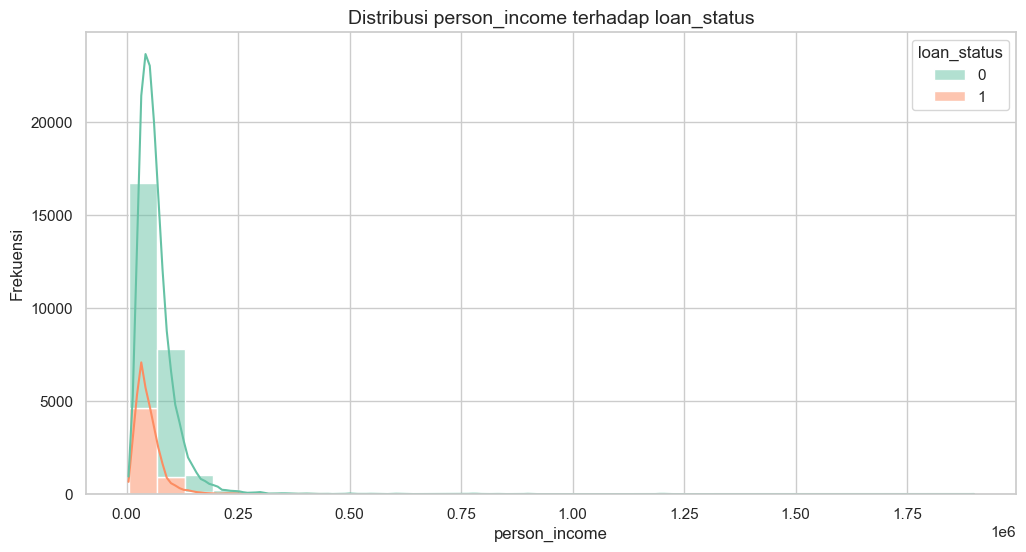

In [117]:
plot_distribution(df_viz, "person_income")

In [118]:
dt_bins_income = get_dt_bin_edges(df_viz, "person_income")

-> Titik potong DT untuk 'person_income': [-inf, np.float64(22806.0), np.float64(28994.5), np.float64(34999.5), np.float64(53948.5), np.float64(59982.0), np.float64(79994.0), inf]


In [119]:
sum_income_dt = evaluate_binning(df_viz, "person_income", dt_bins_income)
sum_income_dt

,Total_Nasabah,Total_GalBay,Bad_Rate %
person_income_binned,,,
"(-inf, 22806.0]",1300,828,63.692308
"(22806.0, 28994.5]",1464,442,30.191257
"(28994.5, 34999.5]",2225,962,43.235955
"(34999.5, 53948.5]",7209,1504,20.862810
"(53948.5, 59982.0]",1921,521,27.121291
"(59982.0, 79994.0]",5428,830,15.291083
"(79994.0, inf]",6407,587,9.161854


In [120]:
final_bins_income = [-np.inf, 35000, 60000, 80000, np.inf]
sum_income_final = evaluate_binning(df_viz, "person_income", final_bins_income)
sum_income_final

,Total_Nasabah,Total_GalBay,Bad_Rate %
person_income_binned,,,
"(-inf, 35000.0]",5317,2288,43.031785
"(35000.0, 60000.0]",9632,2038,21.158638
"(60000.0, 80000.0]",4942,772,15.621206
"(80000.0, inf]",6063,576,9.500247


In [121]:
save_to_config("bin_person_income", [float("-inf"), 35000.0, 60000.0, 80000.0, float("inf")])

Berhasil menyimpan permanen: 'bin_person_income' ke config.yaml


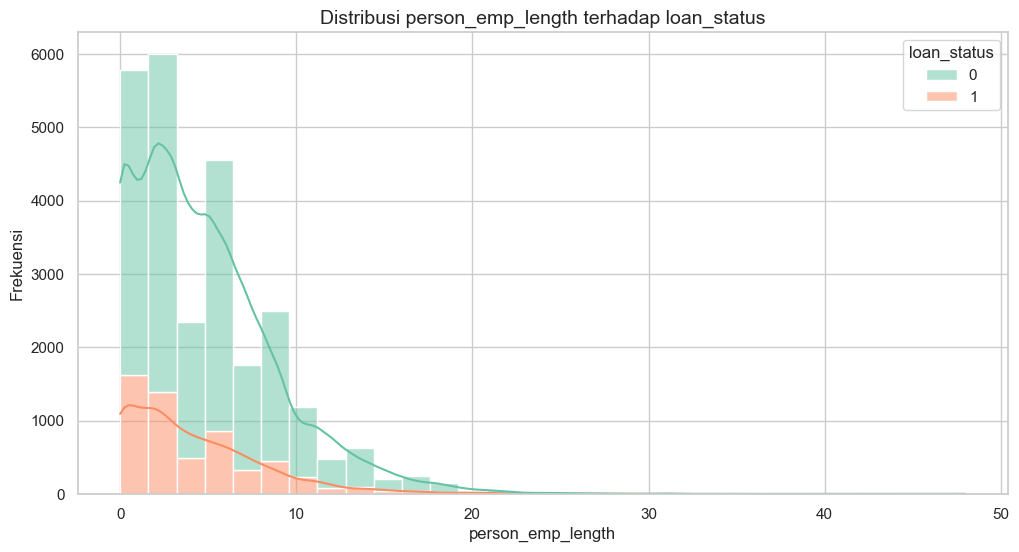

In [122]:
plot_distribution(df_viz, "person_emp_length")

In [123]:
dt_bins_emp = get_dt_bin_edges(df_viz, "person_emp_length")

-> Titik potong DT untuk 'person_emp_length': [-inf, np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(11.5), inf]


In [124]:
summary_emp = evaluate_binning(df_viz, "person_emp_length", dt_bins_emp)
summary_emp

,Total_Nasabah,Total_GalBay,Bad_Rate %
person_emp_length_binned,,,
"(-inf, 0.5]",3382,958,28.326434
"(0.5, 1.5]",2395,658,27.473904
"(1.5, 2.5]",3137,800,25.502072
"(2.5, 3.5]",2861,585,20.447396
"(3.5, 4.5]",2347,497,21.175969
"(4.5, 11.5]",9990,1872,18.738739
"(11.5, inf]",1842,304,16.503800


In [125]:
final_bins_emp = [float("-inf"), 0.5, 1.5, 2.5, 4.5, 11.5, float("inf")]
summary_emp_final = evaluate_binning(df_viz, "person_emp_length", final_bins_emp)
summary_emp_final

,Total_Nasabah,Total_GalBay,Bad_Rate %
person_emp_length_binned,,,
"(-inf, 0.5]",3382,958,28.326434
"(0.5, 1.5]",2395,658,27.473904
"(1.5, 2.5]",3137,800,25.502072
"(2.5, 4.5]",5208,1082,20.775730
"(4.5, 11.5]",9990,1872,18.738739
"(11.5, inf]",1842,304,16.503800


In [126]:
save_to_config("bin_person_emp_length", final_bins_emp)

Berhasil menyimpan permanen: 'bin_person_emp_length' ke config.yaml


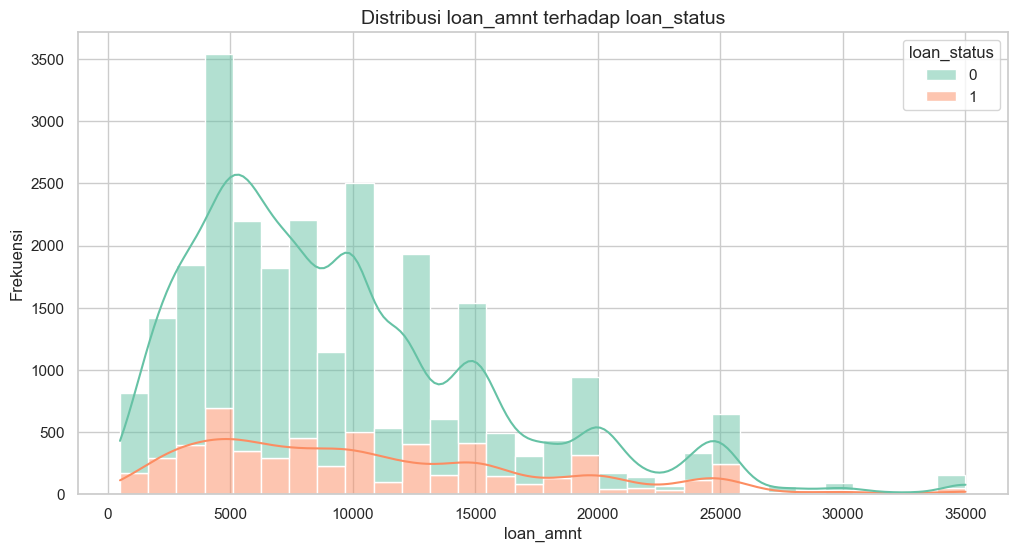

In [127]:
plot_distribution(df_viz, "loan_amnt")

In [128]:
dt_bins_loanAmnt = get_dt_bin_edges(df_viz, "loan_amnt")

-> Titik potong DT untuk 'loan_amnt': [-inf, np.float64(2025.0), np.float64(3475.0), np.float64(7387.5), np.float64(12675.0), np.float64(18087.5), np.float64(22150.0), inf]


In [129]:
summary_loanAmnt = evaluate_binning(df_viz, "loan_amnt", dt_bins_loanAmnt)
summary_loanAmnt

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_amnt_binned,,,
"(-inf, 2025.0]",1425,281,19.719298
"(2025.0, 3475.0]",2035,461,22.653563
"(3475.0, 7387.5]",8179,1437,17.569385
"(7387.5, 12675.0]",7987,1590,19.907349
"(12675.0, 18087.5]",3602,964,26.762909
"(18087.5, 22150.0]",1334,440,32.983508
"(22150.0, inf]",1392,501,35.991379


In [130]:
final_bins_loanAmnt = [float("-inf"), 7500.0, 12500.0, 18000.0, 22000.0, float("inf")]
summary_loanAmnt_final = evaluate_binning(df_viz, "loan_amnt", final_bins_loanAmnt)
summary_loanAmnt_final

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_amnt_binned,,,
"(-inf, 7500.0]",12108,2274,18.780971
"(7500.0, 12500.0]",7503,1493,19.898707
"(12500.0, 18000.0]",3615,966,26.721992
"(18000.0, 22000.0]",1335,440,32.958801
"(22000.0, inf]",1393,501,35.965542


In [131]:
save_to_config("bin_loan_amnt", final_bins_loanAmnt)

Berhasil menyimpan permanen: 'bin_loan_amnt' ke config.yaml


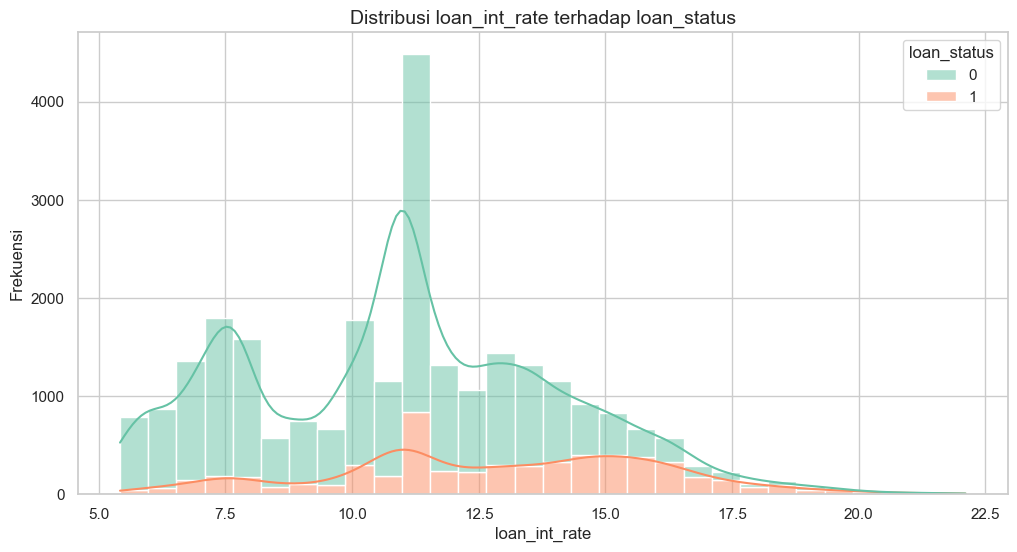

In [132]:
plot_distribution(df_viz, "loan_int_rate")

In [133]:
dt_bins_intRate = get_dt_bin_edges(df_viz, "loan_int_rate")

-> Titik potong DT untuk 'loan_int_rate': [-inf, np.float64(6.5), np.float64(9.6), np.float64(13.1), np.float64(14.4), np.float64(15.3), inf]


In [134]:
summary_intRate = evaluate_binning(df_viz, "loan_int_rate", dt_bins_intRate)
summary_intRate

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_int_rate_binned,,,
"(-inf, 6.5]",1652,106,6.416465
"(6.5, 9.6]",6260,696,11.118211
"(9.6, 13.1]",11438,2074,18.132541
"(13.1, 14.4]",2802,707,25.231977
"(14.4, 15.3]",1459,675,46.264565
"(15.3, inf]",2343,1416,60.435339


In [135]:
final_bins_intRate = [float("-inf"), 6.5, 9.5, 13, 14.5, 15.5, float("inf")]
final_sum_intRate = evaluate_binning(df_viz, "loan_int_rate", final_bins_intRate)
final_sum_intRate

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_int_rate_binned,,,
"(-inf, 6.5]",1652,106,6.416465
"(6.5, 9.5]",6254,696,11.128878
"(9.5, 13.0]",11324,2052,18.120805
"(13.0, 14.5]",3040,798,26.250000
"(14.5, 15.5]",1531,712,46.505552
"(15.5, inf]",2153,1310,60.845332


In [136]:
save_to_config("bin_loan_int_rate", final_bins_intRate)

Berhasil menyimpan permanen: 'bin_loan_int_rate' ke config.yaml


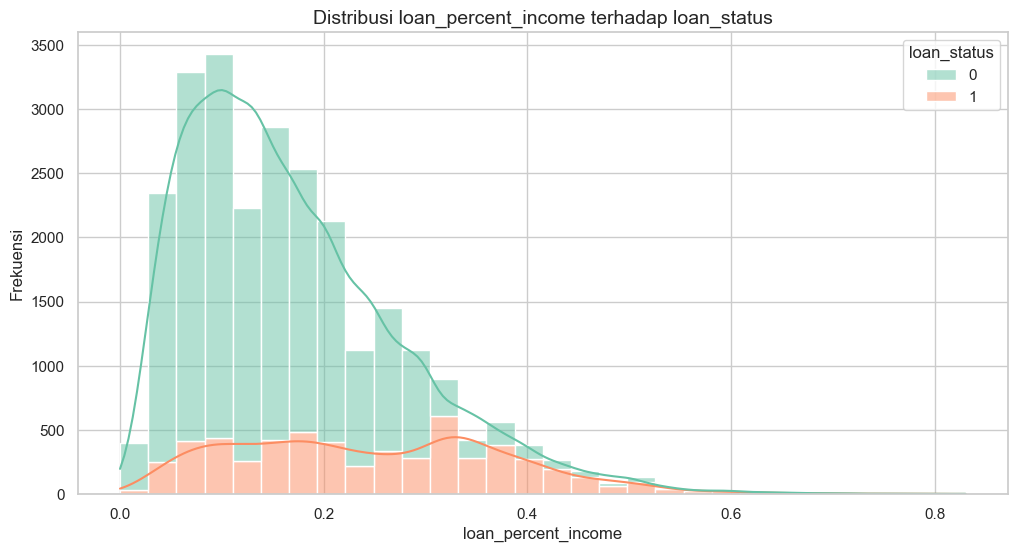

In [137]:
plot_distribution(df_viz, "loan_percent_income")

In [138]:
dt_bins_percentIncome = get_dt_bin_edges(df_viz, "loan_percent_income")

-> Titik potong DT untuk 'loan_percent_income': [-inf, np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), inf]


In [139]:
summary_percentIncome = evaluate_binning(df_viz, "loan_percent_income", dt_bins_percentIncome)
summary_percentIncome

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_percent_income_binned,,,
"(-inf, 0.1]",8348,977,11.703402
"(0.1, 0.2]",9576,1454,15.183793
"(0.2, 0.3]",4980,1103,22.148594
"(0.3, 0.4]",2167,1476,68.112598
"(0.4, inf]",883,664,75.198188


In [140]:
final_bins_percentIncome = [float("-inf"), 0.1, 0.2, 0.3, 0.4, float("inf")]
final_sum_percentIncome = evaluate_binning(df_viz, "loan_percent_income", final_bins_percentIncome)
final_sum_percentIncome

,Total_Nasabah,Total_GalBay,Bad_Rate %
loan_percent_income_binned,,,
"(-inf, 0.1]",8348,977,11.703402
"(0.1, 0.2]",9576,1454,15.183793
"(0.2, 0.3]",4980,1103,22.148594
"(0.3, 0.4]",2167,1476,68.112598
"(0.4, inf]",883,664,75.198188


In [141]:
save_to_config("bin_loan_percent_income", final_bins_percentIncome)

Berhasil menyimpan permanen: 'bin_loan_percent_income' ke config.yaml


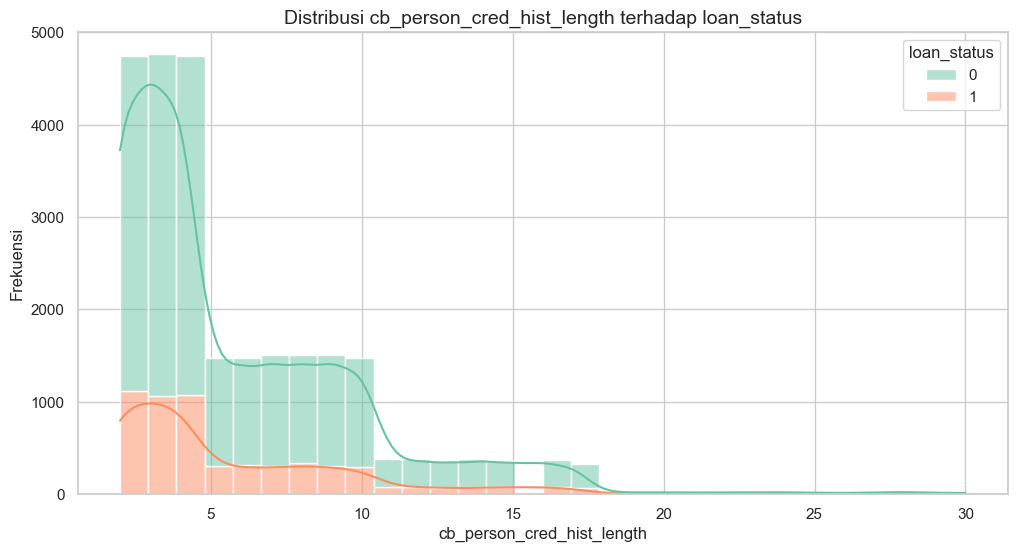

In [142]:
plot_distribution(df_viz, "cb_person_cred_hist_length")

In [143]:
dt_bins_credLength = get_dt_bin_edges(df_viz, "cb_person_cred_hist_length")

-> Titik potong DT untuk 'cb_person_cred_hist_length': [-inf, np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(8.5), np.float64(13.5), inf]


In [144]:
summary_credLength = evaluate_binning(df_viz, "cb_person_cred_hist_length", dt_bins_credLength)
summary_credLength

,Total_Nasabah,Total_GalBay,Bad_Rate %
cb_person_cred_hist_length_binned,,,
"(-inf, 2.5]",4748,1115,23.483572
"(2.5, 3.5]",4767,1057,22.173275
"(3.5, 4.5]",4740,1076,22.700422
"(4.5, 8.5]",5953,1250,20.997816
"(8.5, 13.5]",4095,821,20.048840
"(13.5, inf]",1651,355,21.502120


In [145]:
final_bins_credLength = [float("-inf"), 2.5, 4.5, 8.5, float("inf")]
final_sum_credLength = evaluate_binning(df_viz, "cb_person_cred_hist_length", final_bins_credLength)
final_sum_credLength

,Total_Nasabah,Total_GalBay,Bad_Rate %
cb_person_cred_hist_length_binned,,,
"(-inf, 2.5]",4748,1115,23.483572
"(2.5, 4.5]",9507,2133,22.436100
"(4.5, 8.5]",5953,1250,20.997816
"(8.5, inf]",5746,1176,20.466411


In [146]:
save_to_config("bin_cb_person_cred_hist_length", final_bins_credLength)

Berhasil menyimpan permanen: 'bin_cb_person_cred_hist_length' ke config.yaml


In [147]:
def evaluate_categorical(data: pd.DataFrame, feature_col: str, target_col: str = "loan_status") -> pd.DataFrame:
    """
    Mengevaluasi Bad Rate dan persentase populasi untuk fitur kategorikal.
    """
    df_temp = data.copy()
    
    summary = df_temp.groupby(feature_col, observed=False).agg(
        Total_Nasabah=(target_col, "count"),
        Total_GalBay=(target_col, "sum")
    )
 
    summary["Bad_Rate %"] = (summary["Total_GalBay"] / summary["Total_Nasabah"]) * 100

    total_data = len(df_temp)
    summary["Proporsi_Populasi %"] = (summary["Total_Nasabah"] / total_data) * 100
    
    summary = summary.sort_values(by="Bad_Rate %", ascending=False)
    
    return summary

In [148]:
display(evaluate_categorical(df_viz, "person_home_ownership"))

,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
person_home_ownership,,,,
RENT,13093,4146,31.665776,50.446945
OTHER,87,26,29.885057,0.335208
MORTGAGE,10691,1344,12.571322,41.192109
OWN,2083,158,7.585214,8.025738


In [149]:
display(evaluate_categorical(df_viz, "loan_intent"))

,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
loan_intent,,,,
DEBTCONSOLIDATION,4156,1194,28.729548,16.012946
MEDICAL,4798,1280,26.677782,18.486553
HOMEIMPROVEMENT,2880,764,26.527778,11.096555
PERSONAL,4405,863,19.591373,16.972336
EDUCATION,5144,887,17.243390,19.819681
VENTURE,4571,686,15.007657,17.611929


In [150]:
display(evaluate_categorical(df_viz, "loan_grade"))


,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
loan_grade,,,,
G,48,47,97.916667,0.184943
F,201,139,69.154229,0.774447
E,762,488,64.041995,2.935964
D,2901,1687,58.152361,11.177468
C,5132,1090,21.239283,19.773445
B,8321,1362,16.368225,32.060569
A,8589,861,10.024450,33.093165


In [151]:
display(evaluate_categorical(df_viz, "cb_person_default_on_file"))


,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
cb_person_default_on_file,,,,
Y,4604,1747,37.945265,17.739077
N,21350,3927,18.393443,82.260923


In [152]:
cat_mapping = {
    "person_home_ownership": {
        "OTHER": "RENT" 
    },
    "loan_grade": {
        "G": "D",
        "F": "D",
        "E": "D"
    }
}

for col, mapping in cat_mapping.items():
    df_viz[col] = df_viz[col].replace(mapping)

display(evaluate_categorical(df_viz, "person_home_ownership"))
display(evaluate_categorical(df_viz, "loan_grade"))

,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
person_home_ownership,,,,
RENT,13180,4172,31.654021,50.782153
MORTGAGE,10691,1344,12.571322,41.192109
OWN,2083,158,7.585214,8.025738


,Total_Nasabah,Total_GalBay,Bad_Rate %,Proporsi_Populasi %
loan_grade,,,,
D,3912,2361,60.352761,15.072821
C,5132,1090,21.239283,19.773445
B,8321,1362,16.368225,32.060569
A,8589,861,10.024450,33.093165


In [153]:
save_to_config("categorical_grouping", cat_mapping)

Berhasil menyimpan permanen: 'categorical_grouping' ke config.yaml


In [154]:
config = load_config()

In [155]:
df_binned = X_train.copy()
cat_mapping = config.get("categorical_grouping", {})
num_bins = {
    "person_age": config["bin_person_age"],
    "person_income": config["bin_person_income"],
    "person_emp_length": config["bin_person_emp_length"],
    "loan_amnt": config["bin_loan_amnt"],
    "loan_int_rate": config["bin_loan_int_rate"],
    "loan_percent_income": config["bin_loan_percent_income"],
    "cb_person_cred_hist_length": config["bin_cb_person_cred_hist_length"]
}

for col, mapping in cat_mapping.items():
    if col in df_binned.columns:
        df_binned[col] = df_binned[col].replace(mapping)
        print(f" -> Berhasil melakukan mapping pada kolom: {col}")

for col, bins in num_bins.items():
    if col in df_binned.columns:
        df_binned[col] = pd.cut(df_binned[col], bins=bins).astype(str)
        print(f" -> Berhasil melakukan binning pada kolom: {col}")

df_binned["loan_status"] = y_train

 -> Berhasil melakukan mapping pada kolom: loan_grade
 -> Berhasil melakukan mapping pada kolom: person_home_ownership
 -> Berhasil melakukan binning pada kolom: person_age
 -> Berhasil melakukan binning pada kolom: person_income
 -> Berhasil melakukan binning pada kolom: person_emp_length
 -> Berhasil melakukan binning pada kolom: loan_amnt
 -> Berhasil melakukan binning pada kolom: loan_int_rate
 -> Berhasil melakukan binning pada kolom: loan_percent_income
 -> Berhasil melakukan binning pada kolom: cb_person_cred_hist_length


In [156]:
df_binned.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
29762,"(28, 100]","(35000.0, 60000.0]",MORTGAGE,"(0.5, 1.5]",DEBTCONSOLIDATION,B,"(-inf, 7500.0]","(9.5, 13.0]","(0.1, 0.2]",N,"(8.5, inf]",0
2714,"(23, 28]","(35000.0, 60000.0]",RENT,"(4.5, 11.5]",PERSONAL,A,"(7500.0, 12500.0]","(6.5, 9.5]","(0.2, 0.3]",N,"(-inf, 2.5]",0
50,"(23, 28]","(60000.0, 80000.0]",RENT,"(2.5, 4.5]",DEBTCONSOLIDATION,D,"(22000.0, inf]","(9.5, 13.0]","(0.3, 0.4]",Y,"(2.5, 4.5]",1
28458,"(28, 100]","(60000.0, 80000.0]",RENT,"(1.5, 2.5]",EDUCATION,C,"(7500.0, 12500.0]","(9.5, 13.0]","(0.1, 0.2]",N,"(4.5, 8.5]",0
3674,"(23, 28]","(-inf, 35000.0]",RENT,"(1.5, 2.5]",VENTURE,B,"(-inf, 7500.0]","(9.5, 13.0]","(0.2, 0.3]",N,"(2.5, 4.5]",1


In [157]:
df_binned.dtypes

person_age                       str
person_income                    str
person_home_ownership         object
person_emp_length                str
loan_intent                   object
loan_grade                    object
loan_amnt                        str
loan_int_rate                    str
loan_percent_income              str
cb_person_default_on_file     object
cb_person_cred_hist_length       str
loan_status                    int64
dtype: object

In [158]:
def calculate_woe_iv_custom(data: pd.DataFrame, feature_col: str, target_col: str = "loan_status"):
    df = data.copy()
    
    total_cakep = (df[target_col] == 0).sum()
    total_galbay = (df[target_col] == 1).sum()
    
    grouped = df.groupby(feature_col, observed=False).agg(
        cakep=(target_col, lambda x: (x == 0).sum()),
        galbay=(target_col, lambda x: (x == 1).sum())
    )
    
    eps = 0.00001
    grouped["persentase_cakep"] = (grouped["cakep"] + eps) / total_cakep
    grouped["persentase_galbay"] = (grouped["galbay"] + eps) / total_galbay
    
    grouped["woe"] = np.log(grouped["persentase_cakep"] / grouped["persentase_galbay"])
    grouped['kontribusi_iv'] = (grouped["persentase_cakep"] - grouped["persentase_galbay"]) * grouped["woe"]
    
    total_iv = grouped["kontribusi_iv"].sum()
    woe_dict = grouped["woe"].to_dict()
    
    return woe_dict, total_iv, grouped

In [159]:
iv_summary = []
woe_mappings = {} 

features = [col for col in df_binned.columns if col != "loan_status"]

for col in features:
    w_dict, t_iv, table = calculate_woe_iv_custom(df_binned, col)
    
    woe_mappings[col] = w_dict
    
    if t_iv < 0.02:
        kekuatan = "Gaguna (buang)"
    elif t_iv < 0.1:
        kekuatan = "Lemah"
    elif t_iv < 0.3:
        kekuatan = "Medium"
    elif t_iv < 0.5:
        kekuatan = "Kuat (sangat prediktif)"
    else:
        kekuatan = "Potensi Leakage" 
        
    iv_summary.append({
        "Nama Fitur": col,
        "Total Information Value": t_iv,
        "Kekuatan Fitur": kekuatan
    })
    
    print(f"=== FITUR: {col.upper()} ===")
    print(f"Total IV: {t_iv:.4f} | Kategori: {kekuatan}")
    display(table[["cakep", "galbay", "persentase_cakep", "persentase_galbay", "woe", "kontribusi_iv"]])
    print("-" * 70, "\n")

=== FITUR: PERSON_AGE ===
Total IV: 0.0056 | Kategori: Gaguna (buang)


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
person_age,,,,,,
"(0, 23]",5349,1661,0.263757,0.292739,-0.104251,3.021343e-03
"(23, 28]",8142,2278,0.401479,0.401480,-0.000003,3.284960e-12
"(28, 100]",6789,1735,0.334763,0.305781,0.090555,2.624527e-03


---------------------------------------------------------------------- 

=== FITUR: PERSON_INCOME ===
Total IV: 0.4472 | Kategori: Kuat (sangat prediktif)


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
person_income,,,,,,
"(-inf, 35000.0]",3029,2288,0.149359,0.403243,-0.993186,0.252154
"(35000.0, 60000.0]",7594,2038,0.374458,0.359182,0.041649,0.000636
"(60000.0, 80000.0]",4170,772,0.205621,0.136059,0.412946,0.028725
"(80000.0, inf]",5487,576,0.270562,0.101516,0.980288,0.165714


---------------------------------------------------------------------- 

=== FITUR: PERSON_HOME_OWNERSHIP ===
Total IV: 0.3781 | Kategori: Kuat (sangat prediktif)


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
person_home_ownership,,,,,,
MORTGAGE,9347,1344,0.460897,0.236870,0.665664,0.149127
OWN,1925,158,0.094921,0.027846,1.226345,0.082257
RENT,9008,4172,0.444181,0.735284,-0.504023,0.146722


---------------------------------------------------------------------- 

=== FITUR: PERSON_EMP_LENGTH ===
Total IV: 0.0536 | Kategori: Lemah


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
person_emp_length,,,,,,
"(-inf, 0.5]",2424,958,0.119527,0.168840,-0.345414,0.017034
"(0.5, 1.5]",1737,658,0.085651,0.115968,-0.303031,0.009187
"(1.5, 2.5]",2337,800,0.115237,0.140994,-0.201729,0.005196
"(11.5, inf]",1538,304,0.075838,0.053578,0.347470,0.007735
"(2.5, 4.5]",4126,1082,0.203452,0.190694,0.064756,0.000826
"(4.5, 11.5]",8118,1872,0.400296,0.329926,0.193336,0.013605


---------------------------------------------------------------------- 

=== FITUR: LOAN_INTENT ===
Total IV: 0.0964 | Kategori: Lemah


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
loan_intent,,,,,,
DEBTCONSOLIDATION,2962,1194,0.146055,0.210434,-0.365185,0.023510
EDUCATION,4257,887,0.209911,0.156327,0.294734,0.015793
HOMEIMPROVEMENT,2116,764,0.104339,0.134649,-0.255026,0.007730
MEDICAL,3518,1280,0.173471,0.225590,-0.262708,0.013692
PERSONAL,3542,863,0.174655,0.152097,0.138291,0.003120
VENTURE,3885,686,0.191568,0.120902,0.460260,0.032525


---------------------------------------------------------------------- 

=== FITUR: LOAN_GRADE ===
Total IV: 0.8236 | Kategori: Potensi Leakage


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
loan_grade,,,,,,
A,7728,861,0.381065,0.151745,0.920770,0.211151
B,6959,1362,0.343146,0.240042,0.357341,0.036843
C,4042,1090,0.199310,0.192104,0.036821,0.000265
D,1551,2361,0.076479,0.416109,-1.693926,0.575307


---------------------------------------------------------------------- 

=== FITUR: LOAN_AMNT ===
Total IV: 0.0802 | Kategori: Lemah


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
loan_amnt,,,,,,
"(-inf, 7500.0]",9834,2274,0.484911,0.400775,0.190565,0.016033
"(12500.0, 18000.0]",2649,966,0.130621,0.170250,-0.264967,0.010500
"(18000.0, 22000.0]",895,440,0.044132,0.077547,-0.563692,0.018836
"(22000.0, inf]",892,501,0.043984,0.088297,-0.696881,0.030881
"(7500.0, 12500.0]",6010,1493,0.296351,0.263130,0.118896,0.003950


---------------------------------------------------------------------- 

=== FITUR: LOAN_INT_RATE ===
Total IV: 0.6533 | Kategori: Potensi Leakage


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
loan_int_rate,,,,,,
"(-inf, 6.5]",1546,106,0.076233,0.018682,1.406246,0.080931
"(13.0, 14.5]",2242,798,0.110552,0.140642,-0.240726,0.007243
"(14.5, 15.5]",819,712,0.040385,0.125485,-1.133735,0.096481
"(15.5, inf]",843,1310,0.041568,0.230878,-1.714556,0.324582
"(6.5, 9.5]",5558,696,0.274063,0.122665,0.803903,0.121710
"(9.5, 13.0]",9272,2052,0.457199,0.361650,0.234443,0.022401


---------------------------------------------------------------------- 

=== FITUR: LOAN_PERCENT_INCOME ===
Total IV: 0.9200 | Kategori: Potensi Leakage


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
loan_percent_income,,,,,,
"(-inf, 0.1]",7371,977,0.363462,0.172189,0.747081,0.142896
"(0.1, 0.2]",8122,1454,0.400493,0.256257,0.446517,0.064404
"(0.2, 0.3]",3877,1103,0.191174,0.194395,-0.016713,0.000054
"(0.3, 0.4]",691,1476,0.034073,0.260134,-2.032692,0.459512
"(0.4, inf]",219,664,0.010799,0.117025,-2.382951,0.253132


---------------------------------------------------------------------- 

=== FITUR: CB_PERSON_DEFAULT_ON_FILE ===
Total IV: 0.1667 | Kategori: Medium


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
cb_person_default_on_file,,,,,,
N,17423,3927,0.859122,0.692104,0.216175,0.036105
Y,2857,1747,0.140878,0.307896,-0.781869,0.130586


---------------------------------------------------------------------- 

=== FITUR: CB_PERSON_CRED_HIST_LENGTH ===
Total IV: 0.0041 | Kategori: Gaguna (buang)


,cakep,galbay,persentase_cakep,persentase_galbay,woe,kontribusi_iv
cb_person_cred_hist_length,,,,,,
"(-inf, 2.5]",3633,1115,0.179142,0.196510,-0.092537,0.001607
"(2.5, 4.5]",7374,2133,0.363609,0.375925,-0.033310,0.000410
"(4.5, 8.5]",4703,1250,0.231903,0.220303,0.051316,0.000595
"(8.5, inf]",4570,1176,0.225345,0.207261,0.083654,0.001513


---------------------------------------------------------------------- 



In [160]:
df_iv_summary = pd.DataFrame(iv_summary)

df_iv_summary = df_iv_summary.sort_values(by="Total Information Value", ascending=False).reset_index(drop=True)

print("=== RANGKUMAN KEKUATAN FITUR (IV SUMMARY) ===")
display(df_iv_summary)

=== RANGKUMAN KEKUATAN FITUR (IV SUMMARY) ===


,Nama Fitur,Total Information Value,Kekuatan Fitur
0,loan_percent_income,0.919998,Potensi Leakage
1,loan_grade,0.823567,Potensi Leakage
2,loan_int_rate,0.653348,Potensi Leakage
3,person_income,0.447230,Kuat (sangat prediktif)
4,person_home_ownership,0.378106,Kuat (sangat prediktif)
5,cb_person_default_on_file,0.166691,Medium
6,loan_intent,0.096369,Lemah
7,loan_amnt,0.080200,Lemah
8,person_emp_length,0.053583,Lemah
9,person_age,0.005646,Gaguna (buang)


In [161]:
PATH_WOE_MAPPINGS = "models/woe_mappings.pkl"

In [162]:
save_to_config("path_woe_mappings", PATH_WOE_MAPPINGS)

Berhasil menyimpan permanen: 'path_woe_mappings' ke config.yaml


In [163]:
config = load_config()

In [164]:
serialize_data(woe_mappings, config["path_woe_mappings"])

In [165]:
data_train_woe = pd.DataFrame()

for col in df_binned.columns:
    if col != "loan_status":
        data_train_woe[col] = df_binned[col].map(woe_mappings[col])

data_train_woe["loan_status"] = df_binned["loan_status"]

In [166]:
data_train_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
29762,0.090555,0.041649,0.665664,-0.303031,-0.365185,0.357341,0.190565,0.234443,0.446517,0.216175,0.083654,0
2714,-0.000003,0.041649,-0.504023,0.193336,0.138291,0.920770,0.118896,0.803903,-0.016713,0.216175,-0.092537,0
50,-0.000003,0.412946,-0.504023,0.064756,-0.365185,-1.693926,-0.696881,0.234443,-2.032692,-0.781869,-0.033310,1
28458,0.090555,0.412946,-0.504023,-0.201729,0.294734,0.036821,0.118896,0.234443,0.446517,0.216175,0.051316,0
3674,-0.000003,-0.993186,-0.504023,-0.201729,0.460260,0.357341,0.190565,0.234443,-0.016713,0.216175,-0.033310,1


In [167]:
path_X_train, path_y_train = config["path_train_clean"]
path_X_valid, path_y_valid = config["path_valid_clean"]
path_X_test, path_y_test = config["path_test_clean"]

In [168]:
X_train = deserialize_data(path_X_train)
y_train = deserialize_data(path_y_train)

X_valid = deserialize_data(path_X_valid)
y_valid = deserialize_data(path_y_valid)

X_test = deserialize_data(path_X_test)
y_test = deserialize_data(path_y_test)

In [169]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29762,45.0,37500.0,MORTGAGE,1.0,DEBTCONSOLIDATION,B,5000.0,11.49,0.13,N,16.0
2714,25.0,50000.0,RENT,5.0,PERSONAL,A,12000.0,7.88,0.24,N,2.0
50,24.0,78000.0,RENT,4.0,DEBTCONSOLIDATION,D,30000.0,10.99,0.38,Y,4.0
28458,31.0,78504.0,RENT,2.0,EDUCATION,C,10000.0,11.41,0.13,N,7.0
3674,26.0,14000.0,RENT,2.0,VENTURE,B,4000.0,10.99,0.29,N,3.0


In [170]:
def data_binning(X, config):
    df_binned = X.copy()
    cat_mapping = config.get("categorical_grouping", {})
    
    num_bins = {
        "person_age": config["bin_person_age"],
        "person_income": config["bin_person_income"],
        "person_emp_length": config["bin_person_emp_length"],
        "loan_amnt": config["bin_loan_amnt"],
        "loan_int_rate": config["bin_loan_int_rate"],
        "loan_percent_income": config["bin_loan_percent_income"],
        "cb_person_cred_hist_length": config["bin_cb_person_cred_hist_length"]
    }
    
    for col, mapping in cat_mapping.items():
        if col in df_binned.columns:
            df_binned[col] = df_binned[col].replace(mapping)
            
    for col, bins in num_bins.items():
        if col in df_binned.columns:
            df_binned[col] = pd.cut(df_binned[col], bins=bins).astype(str)
            
    return df_binned

In [171]:
def data_binned_to_woe(X_binned, woe_mappings):
    X_woe = pd.DataFrame()
    for col in X_binned.columns:
        X_woe[col] = X_binned[col].map(woe_mappings[col]).fillna(0)
    return X_woe

In [172]:
woe_mappings = deserialize_data(config["path_woe_mappings"])

In [173]:
X_train_binned = data_binning(X_train, config)
X_train_woe = data_binned_to_woe(X_train_binned, woe_mappings)

X_valid_binned = data_binning(X_valid, config)
X_valid_woe = data_binned_to_woe(X_valid_binned, woe_mappings)

X_test_binned = data_binning(X_test, config)
X_test_woe = data_binned_to_woe(X_test_binned, woe_mappings)

In [174]:
X_train_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29762,0.090555,0.041649,0.665664,-0.303031,-0.365185,0.357341,0.190565,0.234443,0.446517,0.216175,0.083654
2714,-0.000003,0.041649,-0.504023,0.193336,0.138291,0.920770,0.118896,0.803903,-0.016713,0.216175,-0.092537
50,-0.000003,0.412946,-0.504023,0.064756,-0.365185,-1.693926,-0.696881,0.234443,-2.032692,-0.781869,-0.033310
28458,0.090555,0.412946,-0.504023,-0.201729,0.294734,0.036821,0.118896,0.234443,0.446517,0.216175,0.051316
3674,-0.000003,-0.993186,-0.504023,-0.201729,0.460260,0.357341,0.190565,0.234443,-0.016713,0.216175,-0.033310


In [175]:
X_valid_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
25980,0.090555,0.412946,-0.504023,-0.201729,0.138291,0.357341,-0.264967,0.234443,-0.016713,0.216175,0.051316
13630,-0.104251,0.980288,0.665664,0.193336,-0.262708,0.036821,0.190565,-1.133735,0.747081,-0.781869,-0.033310
16921,-0.000003,0.980288,0.665664,0.064756,-0.365185,0.036821,0.190565,-0.240726,0.747081,0.216175,-0.092537
22683,0.090555,0.041649,0.665664,0.064756,-0.262708,0.920770,0.190565,0.803903,0.747081,0.216175,0.051316
864,-0.000003,0.980288,-0.504023,-0.303031,0.460260,0.357341,-0.563692,0.234443,0.446517,0.216175,-0.033310


In [176]:
X_test_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
22990,0.090555,-0.993186,-0.504023,0.193336,-0.365185,-1.693926,0.118896,-1.714556,-0.016713,-0.781869,0.083654
30233,0.090555,0.041649,-0.504023,0.193336,-0.262708,0.357341,0.190565,0.234443,0.446517,0.216175,0.083654
27415,0.090555,0.980288,0.665664,0.193336,0.138291,0.920770,0.190565,0.803903,0.747081,0.216175,0.051316
17372,-0.000003,0.980288,1.226345,0.064756,0.138291,0.036821,0.118896,-1.133735,0.446517,0.216175,-0.033310
9050,-0.000003,0.041649,0.665664,0.193336,0.460260,0.357341,0.118896,0.234443,0.446517,0.216175,-0.092537


In [177]:
save_to_config(
    key = "path_train_woe",
    value = ["data/modeling_ready/X_train_woe.pkl", "data/modeling_ready/y_train_woe.pkl"]
)

save_to_config(
    key = "path_valid_woe",
    value = ["data/modeling_ready/X_valid_woe.pkl", "data/modeling_ready/y_valid_woe.pkl"]
)

save_to_config(
    key = "path_test_woe",
    value = ["data/modeling_ready/X_test_woe.pkl", "data/modeling_ready/y_test_woe.pkl"]
)

Berhasil menyimpan permanen: 'path_train_woe' ke config.yaml
Berhasil menyimpan permanen: 'path_valid_woe' ke config.yaml
Berhasil menyimpan permanen: 'path_test_woe' ke config.yaml


In [178]:
config = load_config()

In [179]:
path_X_train_woe, path_y_train_woe = config["path_train_woe"]
path_X_valid_woe, path_y_valid_woe = config["path_valid_woe"]
path_X_test_woe, path_y_test_woe = config["path_test_woe"]

In [180]:
serialize_data(X_train_woe, path_X_train_woe)
serialize_data(y_train, path_y_train_woe)

serialize_data(X_valid_woe, path_X_valid_woe)
serialize_data(y_valid, path_y_valid_woe)

serialize_data(X_test_woe, path_X_test_woe)
serialize_data(y_test, path_y_test_woe)